# Análise Exploratória - PNS 2019

Análise exploratória dos dados da Pesquisa Nacional de Saúde (PNS) 2019.

Objetivo: explorar relações entre determinantes sociais e doenças crônicas.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import geopandas as gpd

from pathlib import Path

# configuracoes
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_palette('Set2')
plt.style.use('seaborn-v0_8-whitegrid')
malha_territorial = gpd.read_file("../ibge-official-files/BR_UF_2024.shp")

# importar modulos locais
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from selection import select_features
from preprocessing import clean_pns_data
from feature_engineering import apply_feature_engineering
from transformation import apply_transformations

In [12]:
# reiniciar o kernel para recarregar os modulos atualizados
import importlib
import sys

# remover modulos em cache
mods_to_remove = [m for m in sys.modules if 'src.' in m or m in ['selection', 'preprocessing', 'feature_engineering', 'transformation']]
for m in mods_to_remove:
    del sys.modules[m]

print(f"Removidos {len(mods_to_remove)} modulos em cache")
print("Recarregando modulos...")

Removidos 4 modulos em cache
Recarregando modulos...


## 1. Carregar dados selecionados

Carregar os dados já selecionados (features de interesse)

In [13]:
# selecionar features do dataset bruto
df_selected = select_features()

print(f"Dados carregados: {df_selected.shape[0]:,} registros x {df_selected.shape[1]} variaveis")
print(f"\nColunas: {list(df_selected.columns)}")

Features selecionadas salvas em: d:\Workspace\TCCII\data\processed\pns_2019_selected.csv
   Shape: (293726, 37)
Dados carregados: 293,726 registros x 37 variaveis

Colunas: ['uf', 'situacao_domicilio', 'tipo_domicilio', 'agua_canalizada', 'acesso_internet', 'sexo', 'idade', 'raca', 'alfabetizado', 'escolaridade', 'plano_saude', 'renda_domiciliar', 'renda_per_capita', 'peso', 'altura', 'fumante_atual', 'fumou_passado', 'alcool_frequencia', 'alcool_dia_semana', 'atividade_fisica', 'atividade_fisica_frequencia', 'hipertensao', 'diabetes', 'doenca_coracao', 'infarto', 'angina', 'insuficiencia_cardiaca', 'arritmia', 'avc', 'asma', 'artrite', 'dort', 'depressao', 'doenca_pulmao', 'enfisema', 'bronquite', 'insuficiencia_renal']
Dados carregados: 293,726 registros x 37 variaveis

Colunas: ['uf', 'situacao_domicilio', 'tipo_domicilio', 'agua_canalizada', 'acesso_internet', 'sexo', 'idade', 'raca', 'alfabetizado', 'escolaridade', 'plano_saude', 'renda_domiciliar', 'renda_per_capita', 'peso', 'al

## 2. Visão geral dos dados selecionados

Visão geral antes de qualquer processamento

In [14]:
# info basica
df_selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 293726 entries, 0 to 293725
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   uf                           293726 non-null  int64  
 1   situacao_domicilio           293726 non-null  int64  
 2   tipo_domicilio               279382 non-null  float64
 3   agua_canalizada              279382 non-null  float64
 4   acesso_internet              279382 non-null  float64
 5   sexo                         279382 non-null  float64
 6   idade                        279382 non-null  float64
 7   raca                         279382 non-null  float64
 8   alfabetizado                 261595 non-null  float64
 9   escolaridade                 178013 non-null  float64
 10  plano_saude                  279382 non-null  float64
 11  renda_domiciliar             279210 non-null  float64
 12  renda_per_capita             279210 non-null  float64
 13  peso      

In [15]:
# primeiras linhas
df_selected.head(10)

,uf,situacao_domicilio,tipo_domicilio,agua_canalizada,acesso_internet,sexo,idade,raca,alfabetizado,escolaridade,plano_saude,renda_domiciliar,renda_per_capita,peso,altura,fumante_atual,fumou_passado,alcool_frequencia,alcool_dia_semana,atividade_fisica,atividade_fisica_frequencia,hipertensao,diabetes,doenca_coracao,infarto,angina,insuficiencia_cardiaca,arritmia,avc,asma,artrite,dort,depressao,doenca_pulmao,enfisema,bronquite,insuficiencia_renal
0,11,1,1.0,1.0,1.0,2.0,55.0,1.0,1.0,5.0,2.0,2098.0,350.0,60.0,145.0,3.0,1.0,2.0,NaN,1.0,1.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,2.0,2.0,1.0,2.0,1.0,2.0,NaN,NaN,2.0
1,11,1,1.0,1.0,1.0,1.0,69.0,4.0,1.0,NaN,2.0,2098.0,350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11,1,1.0,1.0,1.0,1.0,31.0,2.0,1.0,10.0,2.0,2098.0,350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11,1,1.0,1.0,1.0,1.0,9.0,2.0,1.0,NaN,2.0,2098.0,350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11,1,1.0,1.0,1.0,2.0,6.0,4.0,1.0,NaN,2.0,2098.0,350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,11,1,1.0,1.0,1.0,2.0,4.0,2.0,NaN,NaN,2.0,2098.0,350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,11,1,1.0,1.0,1.0,2.0,33.0,1.0,1.0,7.0,2.0,1000.0,250.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,11,1,1.0,1.0,1.0,1.0,17.0,1.0,1.0,NaN,2.0,1000.0,250.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,11,1,1.0,1.0,1.0,2.0,15.0,4.0,1.0,NaN,2.0,1000.0,250.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,11,1,1.0,1.0,1.0,2.0,19.0,4.0,1.0,10.0,2.0,1000.0,250.0,65.0,152.0,1.0,NaN,2.0,NaN,2.0,NaN,2.0,2.0,2.0,NaN,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0


In [16]:
# estatisticas descritivas
df_selected.describe()

,uf,situacao_domicilio,tipo_domicilio,agua_canalizada,acesso_internet,sexo,idade,raca,alfabetizado,escolaridade,plano_saude,renda_domiciliar,renda_per_capita,peso,altura,fumante_atual,fumou_passado,alcool_frequencia,alcool_dia_semana,atividade_fisica,atividade_fisica_frequencia,hipertensao,diabetes,doenca_coracao,infarto,angina,insuficiencia_cardiaca,arritmia,avc,asma,artrite,dort,depressao,doenca_pulmao,enfisema,bronquite,insuficiencia_renal
count,293726.000000,293726.000000,279382.000000,279382.000000,279382.000000,279382.000000,279382.000000,279382.000000,261595.000000,178013.000000,279382.000000,279210.000000,279210.000000,89954.000000,89954.000000,90846.000000,79460.000000,90846.000000,24323.000000,90846.000000,36398.000000,88736.000000,84073.000000,90846.000000,4732.000000,4732.000000,4732.000000,4732.000000,90846.000000,90846.000000,90846.000000,90846.000000,90846.000000,90846.000000,1279.000000,1279.000000,90846.000000
mean,28.844716,1.236843,1.103457,1.113282,1.199780,1.518788,35.267651,2.735856,1.105457,8.766028,1.790262,4095.075101,1314.001046,71.876637,164.905841,2.762389,2.427888,1.657585,1.861736,1.599344,3.365377,1.731214,1.912291,1.947912,1.707735,1.856932,1.782544,1.560862,1.978260,1.950829,1.920591,1.981166,1.908284,1.985921,1.711493,1.512119,1.985833
std,11.762108,0.425146,0.312296,0.438858,0.399836,0.499648,21.675970,1.418659,0.307142,2.556453,0.407122,6685.171169,2307.681908,15.160030,9.707327,0.636955,0.882790,0.872154,1.691750,0.490034,1.931954,0.443331,0.282874,0.222206,0.454852,0.350180,0.412559,0.496334,0.145834,0.216226,0.270378,0.135940,0.288626,0.117816,0.453245,0.500049,0.118179
min,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,25.000000,128.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,17.000000,1.000000,1.000000,7.000000,2.000000,1371.000000,399.000000,61.000000,158.000000,3.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,27.000000,1.000000,1.000000,1.000000,1.000000,2.000000,34.000000,4.000000,1.000000,10.000000,2.000000,2498.000000,760.000000,70.000000,165.000000,3.000000,3.000000,1.000000,1.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
75%,35.000000,1.000000,1.000000,1.000000,1.000000,2.000000,52.000000,4.000000,1.000000,10.000000,2.000000,4500.000000,1397.000000,80.000000,171.000000,3.000000,3.000000,3.000000,2.000000,2.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,53.000000,2.000000,3.000000,3.000000,2.000000,2.000000,112.000000,9.000000,2.000000,15.000000,2.000000,644998.000000,203196.000000,176.000000,206.000000,3.000000,3.000000,3.000000,7.000000,2.000000,7.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


### Missing values nos dados selecionados

In [17]:
# calcular missing
missing_raw = pd.DataFrame({
    'n_missing': df_selected.isna().sum(),
    'pct_missing': (df_selected.isna().sum() / len(df_selected) * 100).round(2)
}).sort_values('n_missing', ascending=False)

# apenas variaveis com missing
missing_raw[missing_raw['n_missing'] > 0]

,n_missing,pct_missing
bronquite,292447,99.56
enfisema,292447,99.56
arritmia,288994,98.39
infarto,288994,98.39
angina,288994,98.39
insuficiencia_cardiaca,288994,98.39
alcool_dia_semana,269403,91.72
atividade_fisica_frequencia,257328,87.61
fumou_passado,214266,72.95
diabetes,209653,71.38


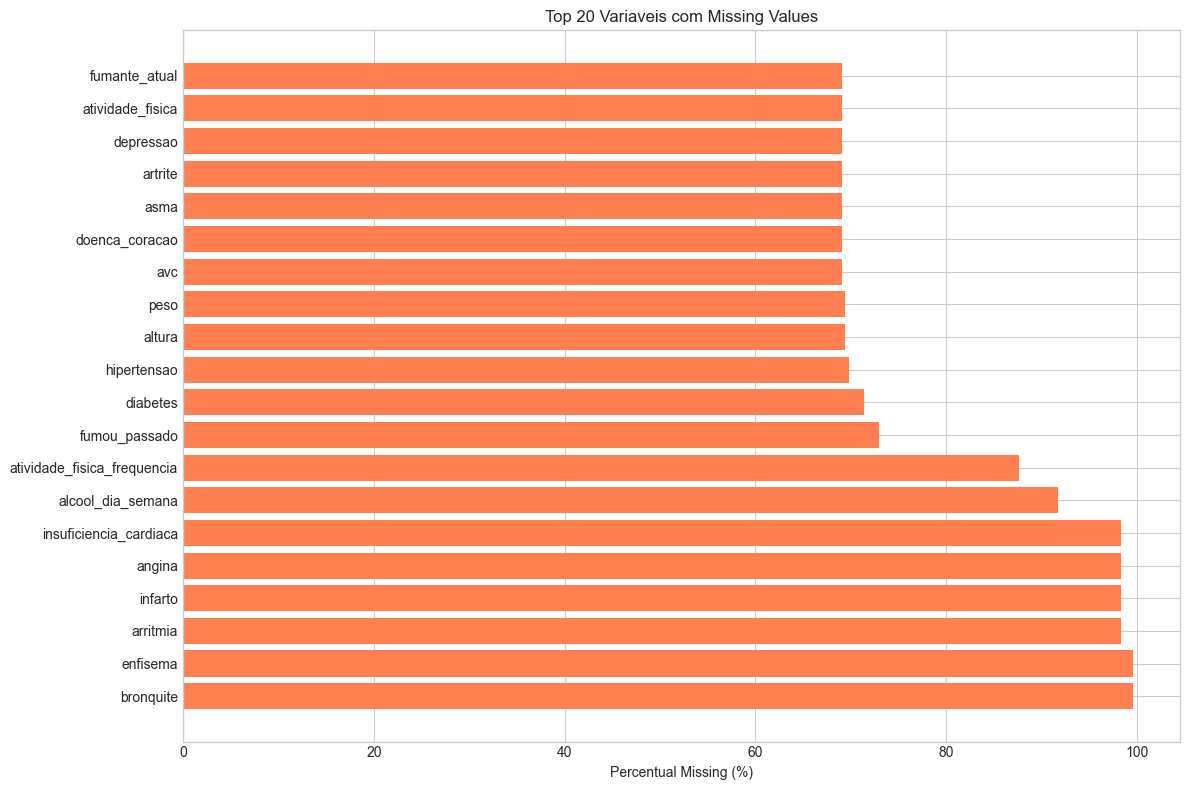

In [18]:
# visualizar top 20 missing
top_missing = missing_raw[missing_raw['n_missing'] > 0].head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_missing)), top_missing['pct_missing'], color='coral')
plt.yticks(range(len(top_missing)), top_missing.index)
plt.xlabel('Percentual Missing (%)')
plt.title('Top 20 Variaveis com Missing Values')
plt.tight_layout()
plt.show()

Muitos missing nos dados selecionados. Isso acontece porque:
- Tem perguntas condicionais (skip patterns)
- As features selecionadas focam no módulo individual (morador selecionado) que contém menos respostas
- Codigo 9 (ignorado/nao sabe)

Filtrar pelo modulo individual (peso) e adultos (>=18 anos)

In [19]:
# filtrar adultos e modulo individual
df = df_selected[(df_selected['idade'] >= 18) & (df_selected['peso'].notna())].copy()

print(f"Antes do filtro: {len(df_selected):,} registros")
print(f"Depois do filtro: {len(df):,} registros")
print(f"Removidos: {len(df_selected) - len(df):,} ({(1 - len(df)/len(df_selected))*100:.1f}%)")

Antes do filtro: 293,726 registros
Depois do filtro: 87,678 registros
Removidos: 206,048 (70.1%)


In [20]:
# recalcular missing apos filtro
missing_filtrado = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('n_missing', ascending=False)

missing_filtrado[missing_filtrado['n_missing'] > 0].head(20)

,n_missing,pct_missing
bronquite,86431,98.58
enfisema,86431,98.58
arritmia,82972,94.63
infarto,82972,94.63
angina,82972,94.63
insuficiencia_cardiaca,82972,94.63
alcool_dia_semana,63681,72.63
atividade_fisica_frequencia,52992,60.44
escolaridade,11896,13.57
fumou_passado,11224,12.80


Agora os missing values se concentram nos casos de skip pattern e ignorados

## 3. Explorar variaveis de doencas

prevalencias das doencas cronicas

In [21]:
# lista de doencas
doencas = [
    'hipertensao', 'diabetes', 'doenca_coracao', 'infarto',
    'angina', 'insuficiencia_cardiaca', 'arritmia',
    'avc', 'asma', 'artrite', 'dort', 'depressao',
    'doenca_pulmao', 'enfisema', 'bronquite', 'insuficiencia_renal'
]

# prevalencia (% de sim = 1)
prevalencias = (df[doencas] == 1).mean().sort_values(ascending=False) * 100
prevalencias

hipertensao               27.052396
depressao                  9.329592
diabetes                   8.352152
artrite                    8.198180
doenca_coracao             5.367367
asma                       4.829034
arritmia                   2.359771
avc                        2.247998
dort                       1.940053
infarto                    1.576222
insuficiencia_renal        1.454185
doenca_pulmao              1.422250
insuficiencia_cardiaca     1.169050
angina                     0.772144
bronquite                  0.684322
enfisema                   0.418577
dtype: float64

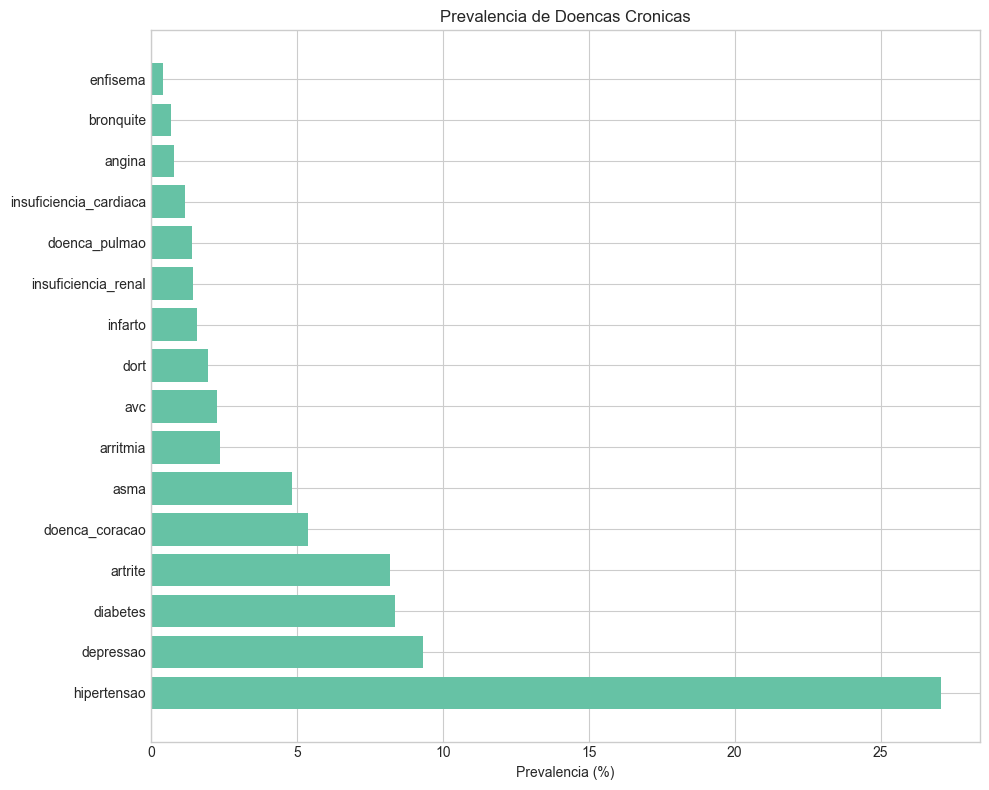

In [22]:
# visualizar prevalencias
plt.figure(figsize=(10, 8))
plt.barh(range(len(prevalencias)), prevalencias.values)
plt.yticks(range(len(prevalencias)), prevalencias.index)
plt.xlabel('Prevalencia (%)')
plt.title('Prevalencia de Doencas Cronicas')
plt.tight_layout()
plt.show()

A prevalencia esta coerente com a literatura brasileira e com a PNS, hipertensão é a DCNT com maior prevalencia, cerca de 27%

## 4. Explorar variaveis sociodemograficas

IDADE
count    87678.000000
mean        47.362349
std         17.094558
min         18.000000
25%         34.000000
50%         46.000000
75%         60.000000
max        107.000000
Name: idade, dtype: float64


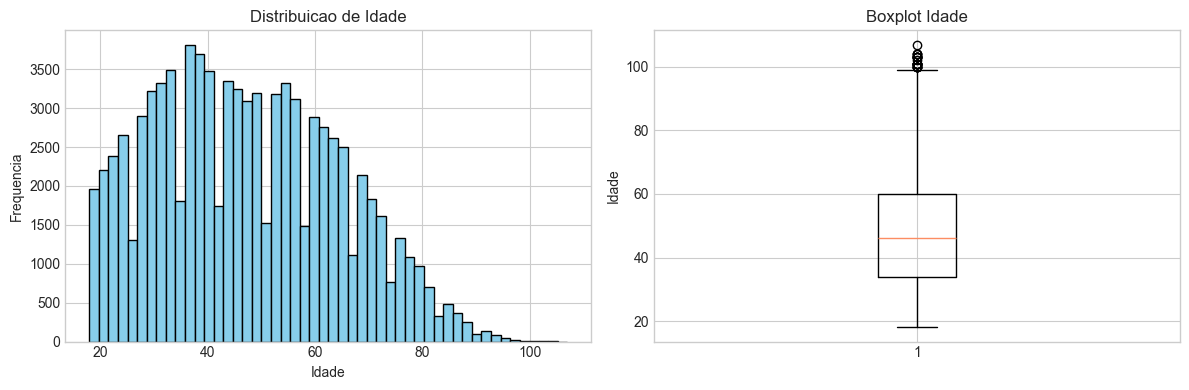

In [23]:
# idade
print("IDADE")
print(df['idade'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['idade'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao de Idade')

axes[1].boxplot(df['idade'])
axes[1].set_ylabel('Idade')
axes[1].set_title('Boxplot Idade')

plt.tight_layout()
plt.show()

SEXO
sexo
2.0    46016
1.0    41662
Name: count, dtype: int64

% Masculino: 47.5%
% Feminino: 52.5%


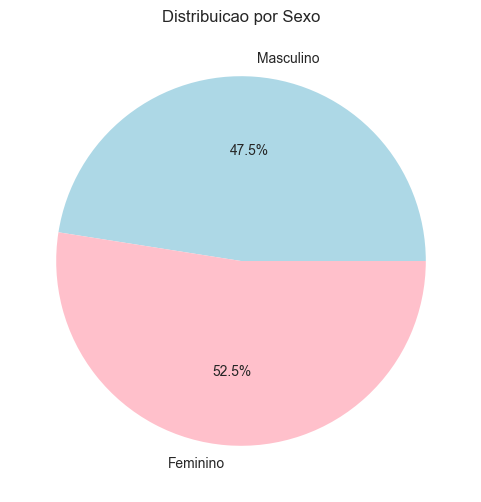

In [24]:
# sexo
print("SEXO")
sexo_dist = df['sexo'].value_counts()
print(sexo_dist)
print(f"\n% Masculino: {(sexo_dist.get(1, 0) / len(df) * 100):.1f}%")
print(f"% Feminino: {(sexo_dist.get(2, 0) / len(df) * 100):.1f}%")

plt.figure(figsize=(6, 6))
plt.pie([sexo_dist.get(1, 0), sexo_dist.get(2, 0)], 
        labels=['Masculino', 'Feminino'],
        autopct='%1.1f%%',
        colors=['lightblue', 'pink'])
plt.title('Distribuicao por Sexo')
plt.show()

RENDA PER CAPITA
count     87657.000000
mean       1618.312559
std        2841.669174
min           0.000000
25%         499.000000
50%         998.000000
75%        1675.000000
max      203196.000000
Name: renda_per_capita, dtype: float64


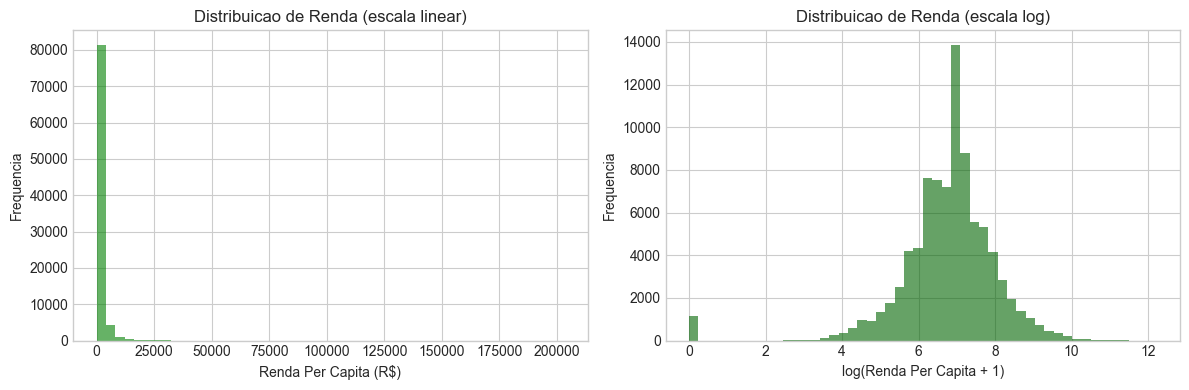


Skewness original: 13.53
Skewness log: -1.80


In [25]:
# renda
print("RENDA PER CAPITA")
print(df['renda_per_capita'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['renda_per_capita'].dropna(), bins=50, color='green', alpha=0.6)
axes[0].set_xlabel('Renda Per Capita (R$)')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao de Renda (escala linear)')

axes[1].hist(np.log1p(df['renda_per_capita'].dropna()), bins=50, color='darkgreen', alpha=0.6)
axes[1].set_xlabel('log(Renda Per Capita + 1)')
axes[1].set_ylabel('Frequencia')
axes[1].set_title('Distribuicao de Renda (escala log)')

plt.tight_layout()
plt.show()

print(f"\nSkewness original: {df['renda_per_capita'].skew():.2f}")
print(f"Skewness log: {np.log1p(df['renda_per_capita'].dropna()).skew():.2f}")

## 5. Relacoes entre variaveis

explorar relações antes do pre proc

In [26]:
df['hipertensao'].value_counts()

hipertensao
2.0    62297
1.0    23719
Name: count, dtype: int64

IDADE POR STATUS DE HIPERTENSAO
Nao hipertensos: media = nan anos
Hipertensos: media = 59.4 anos
Diferenca: nan anos


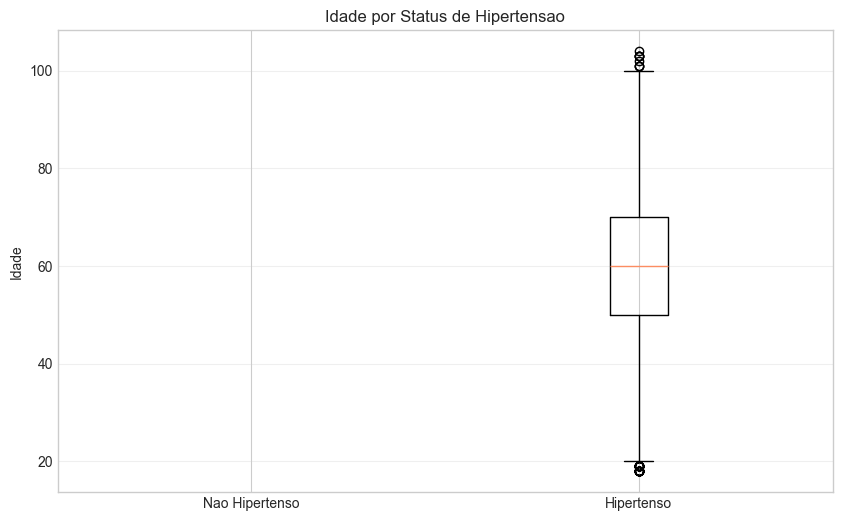

In [27]:
# idade x hipertensao
print("IDADE POR STATUS DE HIPERTENSAO")

df_valid = df[df['hipertensao'].notna()]
idade_nao_hipertenso = df_valid[df_valid['hipertensao'] == 0]['idade']
idade_hipertenso = df_valid[df_valid['hipertensao'] == 1]['idade']

print(f"Nao hipertensos: media = {idade_nao_hipertenso.mean():.1f} anos")
print(f"Hipertensos: media = {idade_hipertenso.mean():.1f} anos")
print(f"Diferenca: {idade_hipertenso.mean() - idade_nao_hipertenso.mean():.1f} anos")

plt.figure(figsize=(10, 6))
plt.boxplot([idade_nao_hipertenso, idade_hipertenso], labels=['Nao Hipertenso', 'Hipertenso'])
plt.ylabel('Idade')
plt.title('Idade por Status de Hipertensao')
plt.grid(axis='y', alpha=0.3)
plt.show()

RENDA POR STATUS DE HIPERTENSAO
Nao hipertensos: media = R$ nan
Hipertensos: media = R$ 1742.13


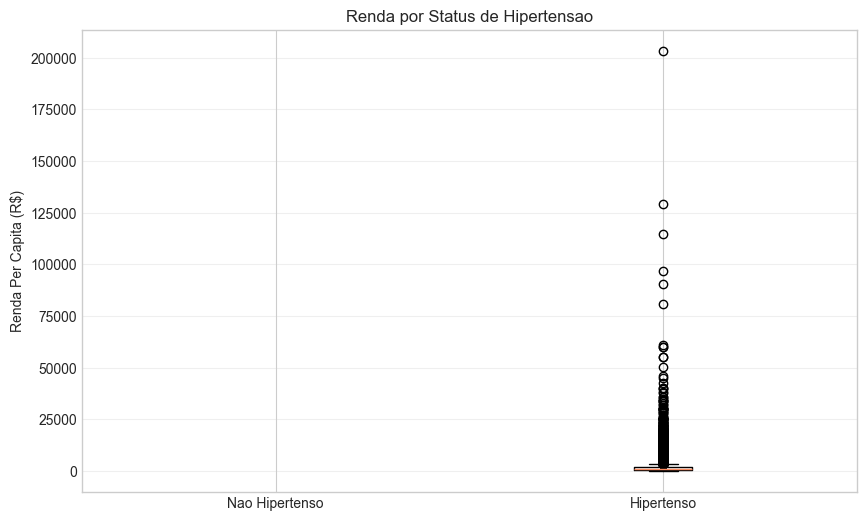

In [28]:
# renda x hipertensao
print("RENDA POR STATUS DE HIPERTENSAO")

renda_nao_hipertenso = df_valid[df_valid['hipertensao'] == 0]['renda_per_capita']
renda_hipertenso = df_valid[df_valid['hipertensao'] == 1]['renda_per_capita']

print(f"Nao hipertensos: media = R$ {renda_nao_hipertenso.mean():.2f}")
print(f"Hipertensos: media = R$ {renda_hipertenso.mean():.2f}")

plt.figure(figsize=(10, 6))
plt.boxplot([renda_nao_hipertenso.dropna(), renda_hipertenso.dropna()], 
            labels=['Nao Hipertenso', 'Hipertenso'])
plt.ylabel('Renda Per Capita (R$)')
plt.title('Renda por Status de Hipertensao')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [29]:
# crosstab sexo x hipertensao
ct = pd.crosstab(df_valid['sexo'], df_valid['hipertensao'], normalize='index') * 100
ct.index = ['Masculino', 'Feminino']
ct.columns = ['Nao Hipertenso (%)', 'Hipertenso (%)']
print("PREVALENCIA DE HIPERTENSAO POR SEXO")
print(ct.round(2))

PREVALENCIA DE HIPERTENSAO POR SEXO
           Nao Hipertenso (%)  Hipertenso (%)
Masculino               23.17           76.83
Feminino                31.50           68.50


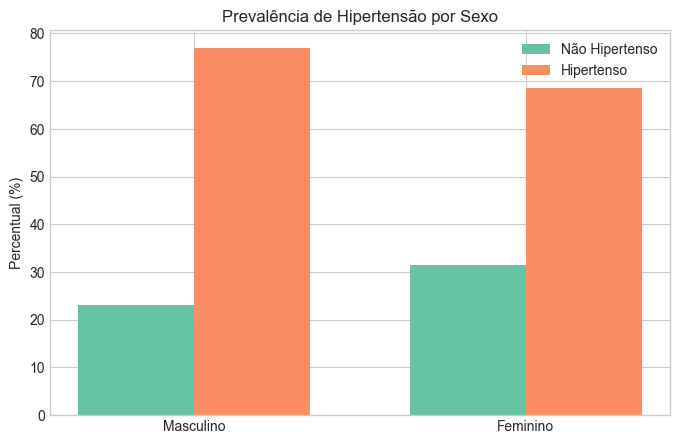

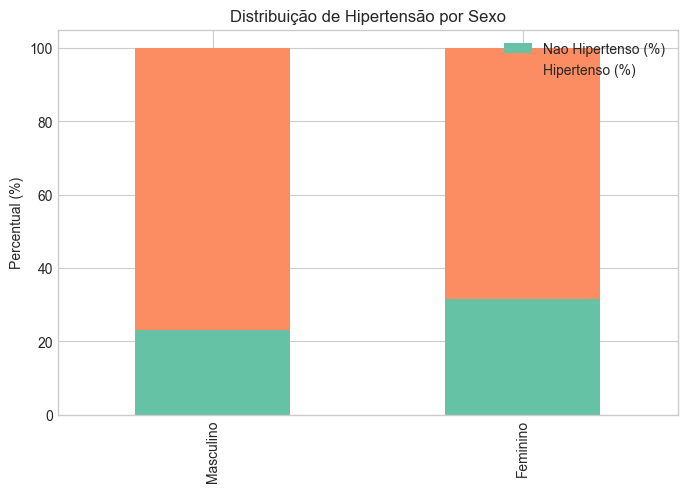

In [30]:
labels = ct.index
nao_hip = ct['Nao Hipertenso (%)']
hip = ct['Hipertenso (%)']

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, nao_hip, width, label='Não Hipertenso')
plt.bar(x + width/2, hip, width, label='Hipertenso')

plt.xticks(x, labels)
plt.ylabel('Percentual (%)')
plt.title('Prevalência de Hipertensão por Sexo')
plt.legend()

plt.show()

ct.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Distribuição de Hipertensão por Sexo')
plt.ylabel('Percentual (%)')
plt.legend(loc='upper right')
plt.show()

## 6. Executar pre-processamento

rodar o pipeline de limpeza, feature engineering e transformacoes

In [31]:
# etapa 1: limpeza
print("ETAPA 1: LIMPEZA")
print("-" * 70)
df_clean = clean_pns_data(df_selected)
print(f"Shape apos limpeza: {df_clean.shape}")

ETAPA 1: LIMPEZA
----------------------------------------------------------------------
Após filtro de público-alvo (com resposta): 89954 registros
Limpeza completa: 87657 registros, 39 features
Shape apos limpeza: (87657, 39)


In [32]:
# verificar variaveis agregadas criadas
print("Variaveis agregadas de multimorbidade criadas:")
print(f"n_doencas: {df_clean['n_doencas'].describe()}")
print(f"\ndoenca_cronica: {df_clean['doenca_cronica'].value_counts()}")

Variaveis agregadas de multimorbidade criadas:
n_doencas: count     87657.0
mean     0.771838
std      1.190015
min           0.0
25%           0.0
50%           0.0
75%           1.0
max          15.0
Name: n_doencas, dtype: Float64

doenca_cronica: doenca_cronica
0    49622
1    38035
Name: count, dtype: Int64


In [33]:
# etapa 2: feature engineering
print("\nETAPA 2: FEATURE ENGINEERING")
print("-" * 70)
df_engineered = apply_feature_engineering(df_clean)
print(f"Shape apos engenharia: {df_engineered.shape}")
print(f"Features criadas: {df_engineered.shape[1] - df_clean.shape[1]}")


ETAPA 2: FEATURE ENGINEERING
----------------------------------------------------------------------
Iniciando engenharia de features: 87657 registros
Engenharia completa: 87657 registros, 68 features
Shape apos engenharia: (87657, 68)
Features criadas: 29


In [34]:
# etapa 3: transformacoes
print("\nETAPA 3: TRANSFORMACOES ESTATISTICAS")
print("-" * 70)
df_final = apply_transformations(df_engineered)
print(f"Shape final: {df_final.shape}")


ETAPA 3: TRANSFORMACOES ESTATISTICAS
----------------------------------------------------------------------
Aplicando transformações estatísticas: 87657 registros
Transformações completas: 87657 registros, 69 features
Shape final: (87657, 69)


In [35]:
# comparar antes e depois das transformacoes
print("\nCOMPARACAO ANTES/DEPOIS TRANSFORMACOES")
print("-" * 70)

# renda
if 'renda_per_capita_log' in df_final.columns:
    print("\nRenda per capita:")
    print(f"  Skewness original: {df_engineered['renda_per_capita'].skew():.2f}")
    print(f"  Skewness log: {df_final['renda_per_capita_log'].skew():.2f}")

# idade
if 'idade_centrada' in df_final.columns:
    print("\nIdade:")
    print(f"  Media original: {df_engineered['idade'].mean():.2f}")
    print(f"  Media centrada: {df_final['idade_centrada'].mean():.2f}")


COMPARACAO ANTES/DEPOIS TRANSFORMACOES
----------------------------------------------------------------------

Renda per capita:
  Skewness original: 13.53
  Skewness log: -1.80


## 7. Analise dos dados processados

exploração dos dados processados

In [36]:
# info geral
df_final.info()

<class 'pandas.DataFrame'>
Index: 87657 entries, 0 to 293720
Data columns (total 69 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   situacao_domicilio      87657 non-null  Int64  
 1   acesso_internet         87657 non-null  Int64  
 2   plano_saude             87657 non-null  float64
 3   hipertensao             85995 non-null  float64
 4   diabetes                81504 non-null  float64
 5   doenca_coracao          87657 non-null  float64
 6   infarto                 87657 non-null  float64
 7   angina                  87657 non-null  float64
 8   insuficiencia_cardiaca  87657 non-null  float64
 9   arritmia                87657 non-null  float64
 10  avc                     87657 non-null  float64
 11  asma                    87657 non-null  float64
 12  artrite                 87657 non-null  float64
 13  dort                    87657 non-null  float64
 14  depressao               87657 non-null  float64
 15  

In [37]:
# missing nos dados finais
missing_final = pd.DataFrame({
    'n_missing': df_final.isna().sum(),
    'pct_missing': (df_final.isna().sum() / len(df_final) * 100).round(2)
}).sort_values('n_missing', ascending=False)

print("Missing values nos dados finais:")
missing_final[missing_final['n_missing'] > 0].head(20)

Missing values nos dados finais:


,n_missing,pct_missing
escolaridade_ord,7267,8.29
diabetes,6153,7.02
hipertensao,1662,1.90


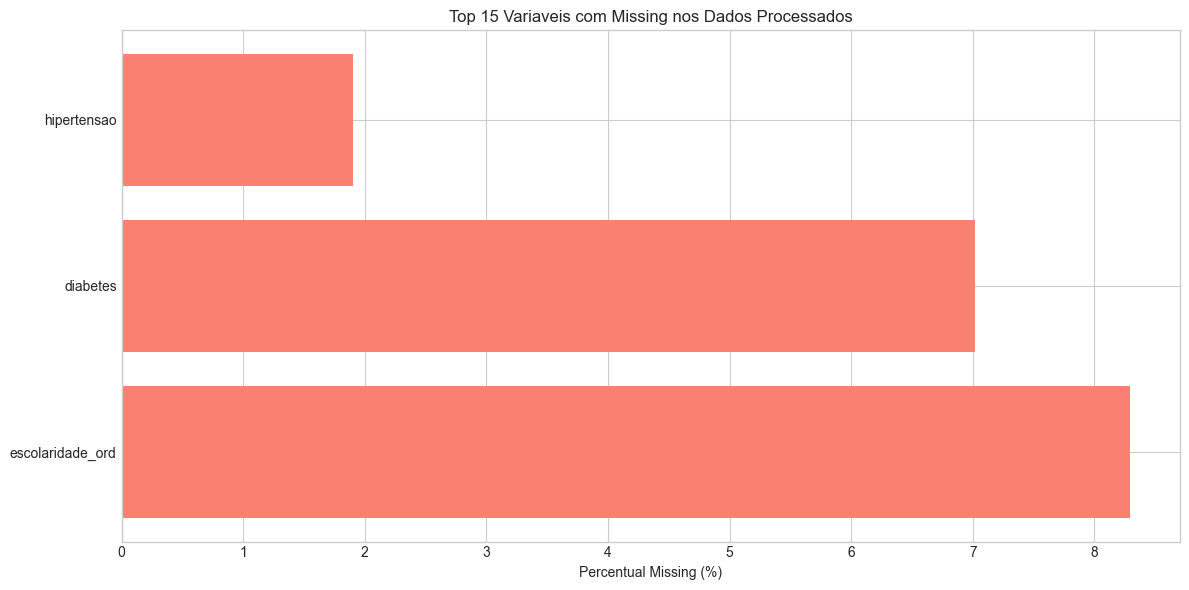

In [38]:
# visualizar missing final
top_missing_final = missing_final[missing_final['n_missing'] > 0].head(15)

if len(top_missing_final) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(top_missing_final)), top_missing_final['pct_missing'], color='salmon')
    plt.yticks(range(len(top_missing_final)), top_missing_final.index)
    plt.xlabel('Percentual Missing (%)')
    plt.title('Top 15 Variaveis com Missing nos Dados Processados')
    plt.tight_layout()
    plt.show()

## 8. Correlacoes

calcular correlacoes entre variaveis numericas

In [39]:
# selecionar apenas numericas
numericas = df_final.select_dtypes(include=[np.number]).columns.tolist()
print(f"Total de variaveis numericas: {len(numericas)}")

Total de variaveis numericas: 32


Top 20 correlacoes com hipertensao:
hipertensao               1.000000
doenca_cronica            0.694776
n_doencas                 0.619705
idade_c                   0.427896
diabetes                  0.259065
imc                       0.197561
doenca_coracao            0.196682
artrite                   0.177083
avc                       0.143856
idade_c2                  0.131558
infarto                   0.129609
arritmia                  0.118798
insuficiencia_cardiaca    0.104245
depressao                 0.097071
angina                    0.094451
sexo_feminino             0.093060
insuficiencia_renal       0.070225
renda_per_capita_log      0.062217
tabagismo_status          0.047622
doenca_pulmao             0.041465
dtype: float64


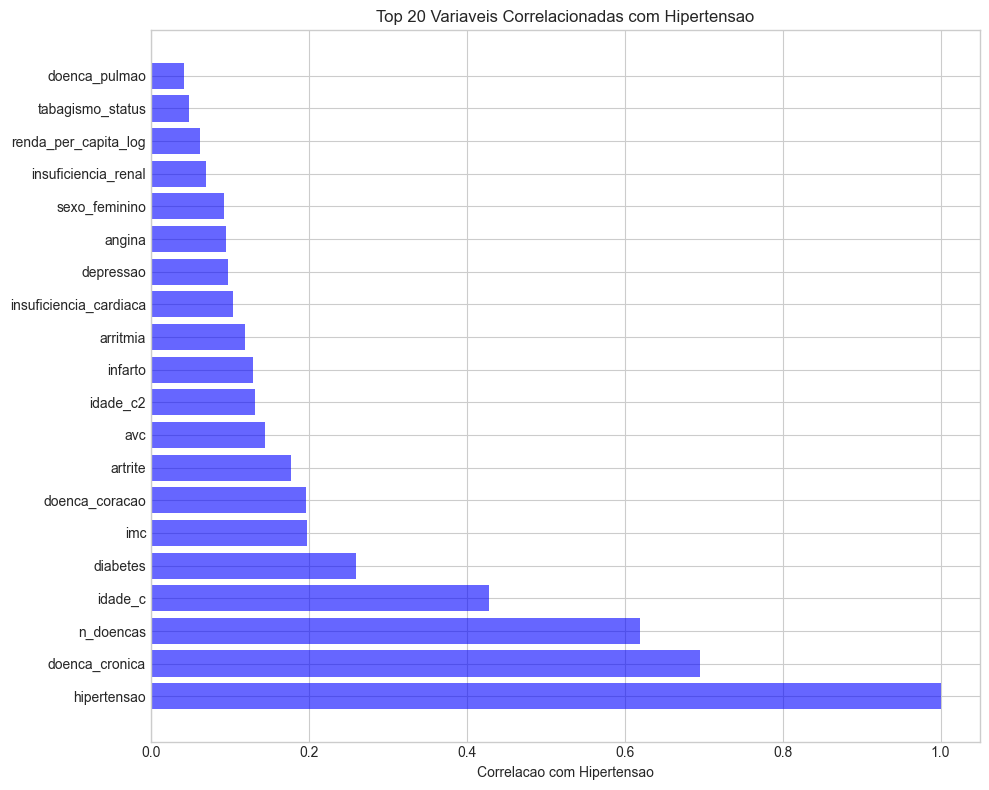

In [40]:
# correlacao com hipertensao
if 'hipertensao' in df_final.columns:
    corr_hipertensao = df_final[numericas].corrwith(df_final['hipertensao']).sort_values(ascending=False)
    
    print("Top 20 correlacoes com hipertensao:")
    print(corr_hipertensao.head(20))
    
    # visualizar
    plt.figure(figsize=(10, 8))
    top_corr = corr_hipertensao.head(20)
    colors = ['red' if x < 0 else 'blue' for x in top_corr.values]
    plt.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.6)
    plt.yticks(range(len(top_corr)), top_corr.index)
    plt.xlabel('Correlacao com Hipertensao')
    plt.title('Top 20 Variaveis Correlacionadas com Hipertensao')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

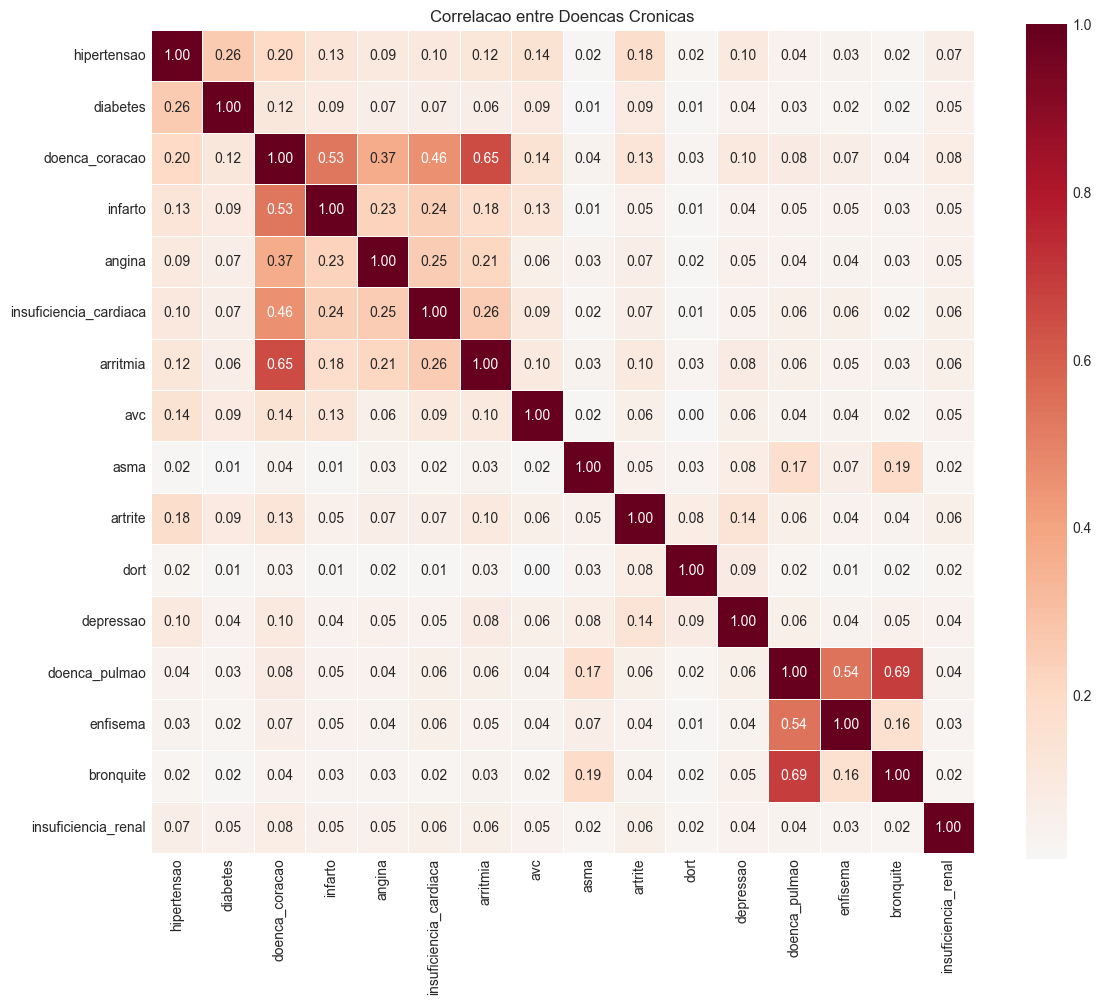

In [41]:
# heatmap de correlacao - variaveis de doencas
doencas_final = [col for col in doencas if col in df_final.columns]

if len(doencas_final) > 0:
    corr_doencas = df_final[doencas_final].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_doencas, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, square=True, linewidths=0.5)
    plt.title('Correlacao entre Doencas Cronicas')
    plt.tight_layout()
    plt.show()

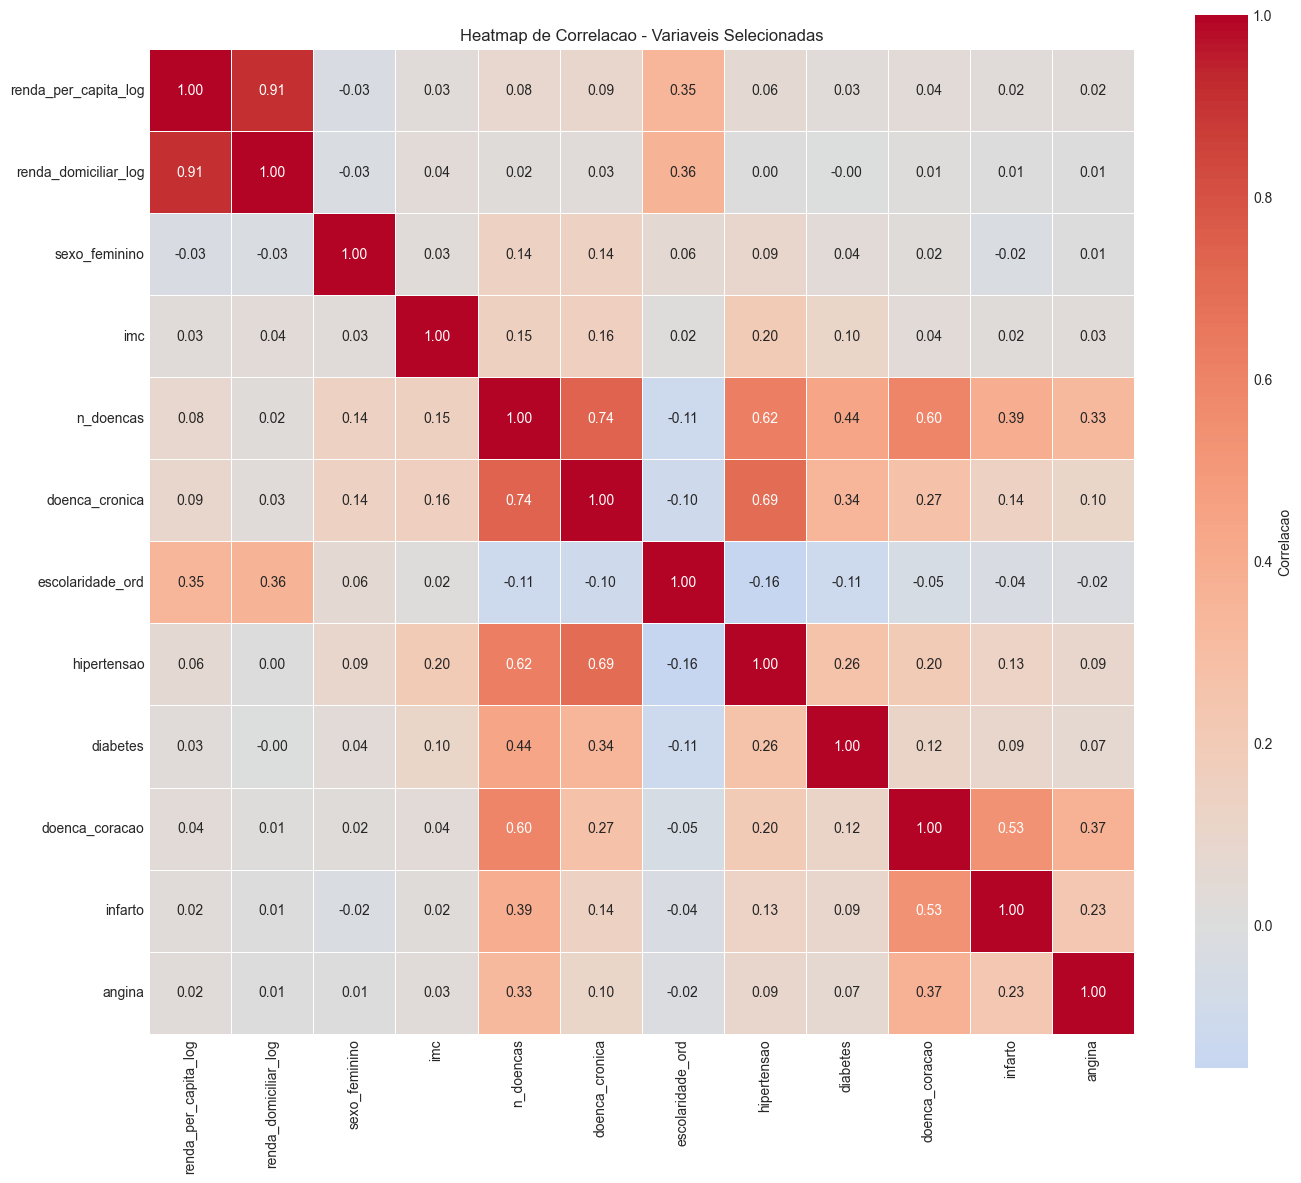

In [42]:
# heatmap geral - amostra de variaveis
# selecionar variaveis de interesse
vars_interesse = ['idade_centrada', 'renda_per_capita_log', 'renda_domiciliar_log',
                  'sexo_feminino', 'imc', 'n_doencas', 'doenca_cronica', 'escolaridade_ord'] + doencas_final[:5]

vars_disponiveis = [v for v in vars_interesse if v in df_final.columns]

if len(vars_disponiveis) > 2:
    corr_interesse = df_final[vars_disponiveis].corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_interesse, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlacao'})
    plt.title('Heatmap de Correlacao - Variaveis Selecionadas')
    plt.tight_layout()
    plt.show()

## 9. Testar diferentes combinacoes

testar algumas relacoes interessantes

NUMERO DE DOENCAS POR FAIXA ETARIA
                  mean  median       std
faixa_etaria                            
18-29         0.648867     0.0  1.016835
30-39         0.881057     0.0   1.22642
40-49         0.710097     0.0  1.082195
50-59         0.701523     0.0  1.085283
60+            0.69829     0.0  1.124562


<Figure size 1000x600 with 0 Axes>

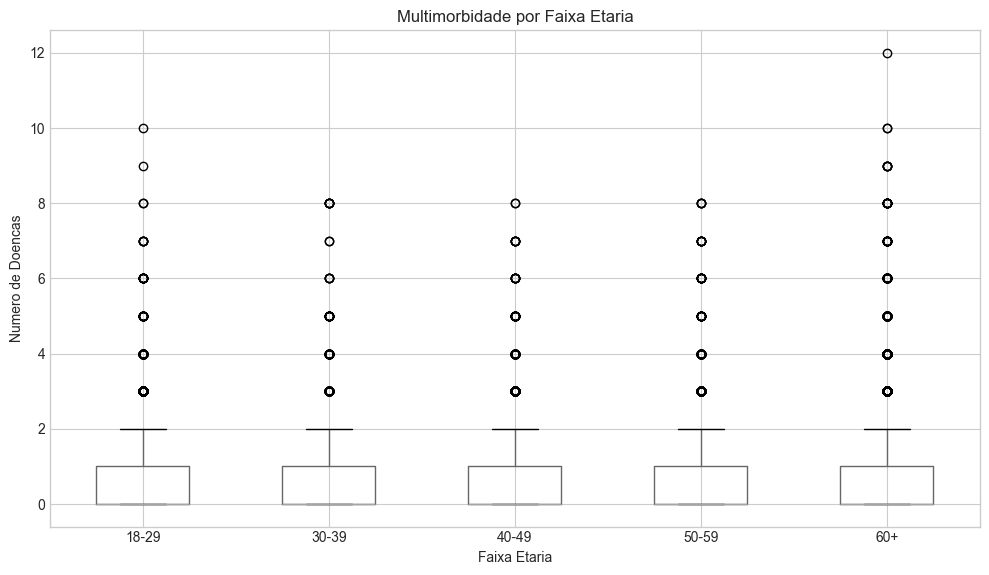

In [43]:
# multimorbidade por faixa etaria
df_final['faixa_etaria'] = pd.cut(df_final['idade_c2'], 
                                   bins=[18, 30, 40, 50, 60, 120],
                                   labels=['18-29', '30-39', '40-49', '50-59', '60+'])

print("NUMERO DE DOENCAS POR FAIXA ETARIA")
by_idade = df_final.groupby('faixa_etaria')['n_doencas'].agg(['mean', 'median', 'std'])
print(by_idade)

plt.figure(figsize=(10, 6))
df_final.boxplot(column='n_doencas', by='faixa_etaria', figsize=(10, 6))
plt.xlabel('Faixa Etaria')
plt.ylabel('Numero de Doencas')
plt.title('Multimorbidade por Faixa Etaria')
plt.suptitle('')
plt.tight_layout()
plt.show()


PREVALENCIA DE HIPERTENSAO POR IDADE E SEXO (%)
sexo_label     Feminino  Masculino
faixa_etaria                      
18-29         26.794438  19.546621
30-39         36.823936  26.449788
40-49         26.704545  20.965608
50-59         28.932262  20.474777
60+           27.506230  21.215855


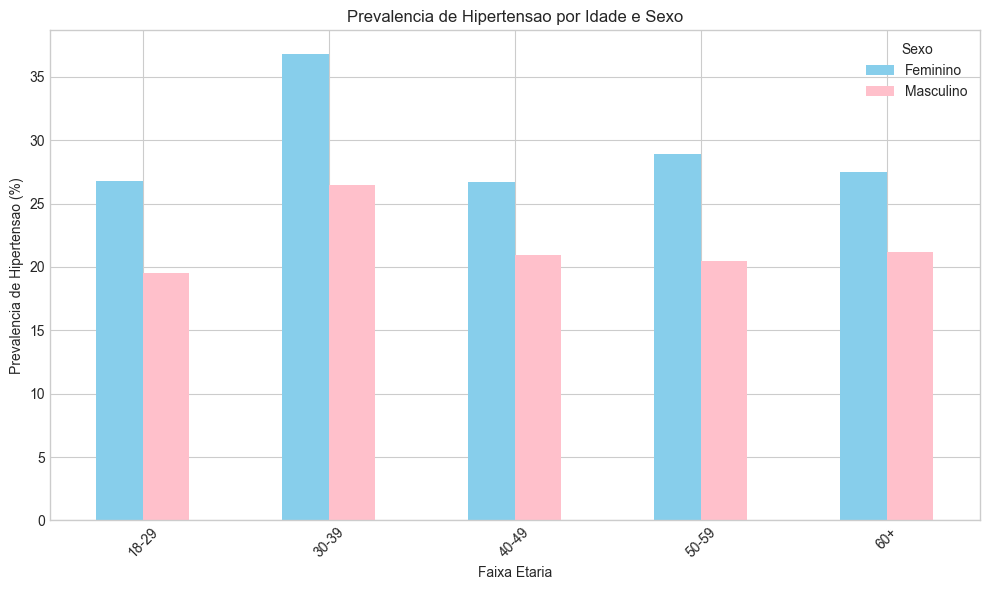

In [44]:
# hipertensao por faixa etaria e sexo
if 'sexo_feminino' in df_final.columns:
    df_final['sexo_label'] = df_final['sexo_feminino'].map({0: 'Masculino', 1: 'Feminino'})
    
    prev_idade_sexo = df_final.groupby(['faixa_etaria', 'sexo_label'])['hipertensao'].mean() * 100
    print("\nPREVALENCIA DE HIPERTENSAO POR IDADE E SEXO (%)")
    print(prev_idade_sexo.unstack())
    
    # visualizar
    prev_idade_sexo.unstack().plot(kind='bar', figsize=(10, 6), color=['skyblue', 'pink'])
    plt.xlabel('Faixa Etaria')
    plt.ylabel('Prevalencia de Hipertensao (%)')
    plt.title('Prevalencia de Hipertensao por Idade e Sexo')
    plt.legend(title='Sexo')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


NUMERO DE DOENCAS POR QUARTIL DE RENDA
                   mean  median
quartil_renda                  
Q1 (baixa)     0.573069     0.0
Q2             0.832154     0.0
Q3             0.803215     0.0
Q4 (alta)      0.878328     0.0


<Figure size 1000x600 with 0 Axes>

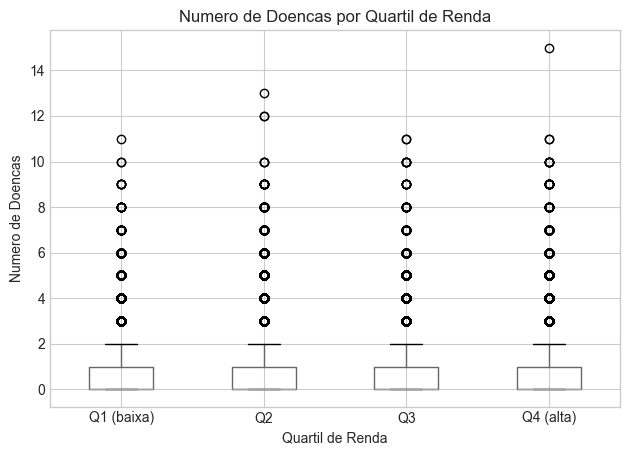

In [45]:
# renda vs numero de doencas
if 'renda_per_capita_log' in df_final.columns:
    # criar quartis de renda
    df_final['quartil_renda'] = pd.qcut(df_final['renda_per_capita_log'], 
                                         q=4, labels=['Q1 (baixa)', 'Q2', 'Q3', 'Q4 (alta)'])
    
    print("\nNUMERO DE DOENCAS POR QUARTIL DE RENDA")
    by_renda = df_final.groupby('quartil_renda')['n_doencas'].agg(['mean', 'median'])
    print(by_renda)
    
    plt.figure(figsize=(10, 6))
    df_final.boxplot(column='n_doencas', by='quartil_renda')
    plt.xlabel('Quartil de Renda')
    plt.ylabel('Numero de Doencas')
    plt.title('Numero de Doencas por Quartil de Renda')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()


PREVALENCIA DE HIPERTENSAO POR CATEGORIA DE IMC (%)
categoria_imc
Baixo peso    18.283166
Normal        19.585004
Sobrepeso     28.799553
Obesidade     41.616230
Name: hipertensao, dtype: float64


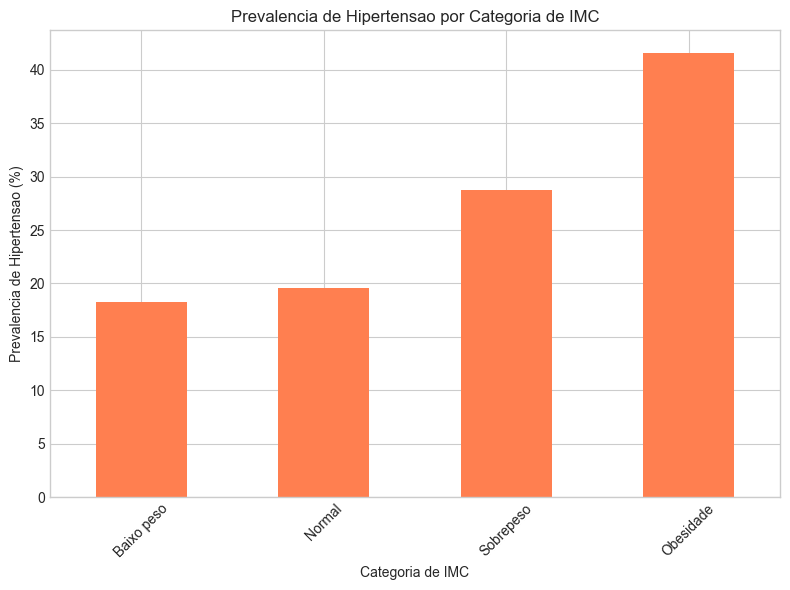

In [46]:
# IMC vs hipertensao
if 'imc' in df_final.columns:
    # categorias de IMC
    df_final['categoria_imc'] = pd.cut(df_final['imc'],
                                        bins=[0, 18.5, 25, 30, 100],
                                        labels=['Baixo peso', 'Normal', 'Sobrepeso', 'Obesidade'])
    
    print("\nPREVALENCIA DE HIPERTENSAO POR CATEGORIA DE IMC (%)")
    prev_imc = df_final.groupby('categoria_imc')['hipertensao'].mean() * 100
    print(prev_imc)
    
    prev_imc.plot(kind='bar', figsize=(8, 6), color='coral')
    plt.xlabel('Categoria de IMC')
    plt.ylabel('Prevalencia de Hipertensao (%)')
    plt.title('Prevalencia de Hipertensao por Categoria de IMC')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 10. Testar variaveis de estilo de vida

PREVALENCIA DE HIPERTENSAO POR STATUS DE TABAGISMO (%)
tabagismo_label
Ex-fumante       36.889608
Fumante atual    23.455991
Nunca fumou      24.209712
Name: hipertensao, dtype: float64


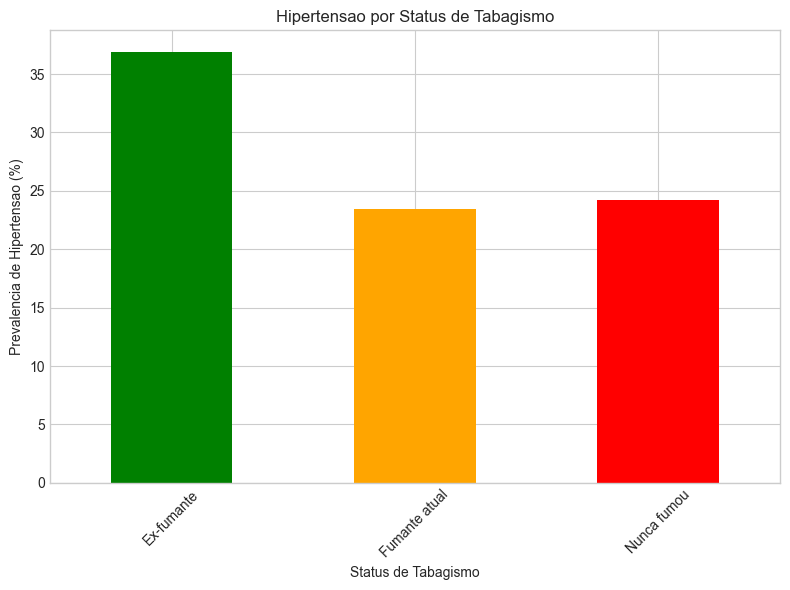


TABAGISMO ATIVO:
tabagismo_ativo
False    76438
True     11219
Name: count, dtype: Int64


In [47]:
# tabagismo vs hipertensao
if 'tabagismo_status' in df_final.columns:
    tabag_labels = {0: 'Nunca fumou', 1: 'Ex-fumante', 2: 'Fumante atual'}
    df_final['tabagismo_label'] = df_final['tabagismo_status'].map(tabag_labels)
    
    print("PREVALENCIA DE HIPERTENSAO POR STATUS DE TABAGISMO (%)")
    prev_tabag = df_final.groupby('tabagismo_label')['hipertensao'].mean() * 100
    print(prev_tabag)
    
    prev_tabag.plot(kind='bar', figsize=(8, 6), color=['green', 'orange', 'red'])
    plt.xlabel('Status de Tabagismo')
    plt.ylabel('Prevalencia de Hipertensao (%)')
    plt.title('Hipertensao por Status de Tabagismo')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("\nTABAGISMO ATIVO:")
    print(df_final['tabagismo_ativo'].value_counts())

PREVALENCIA DE HIPERTENSAO POR NIVEL DE ATIVIDADE FISICA (%)
atividade_label
Alta          25.011385
Baixa freq    20.370535
Moderada      24.132786
Sedentario    30.340873
Name: hipertensao, dtype: float64


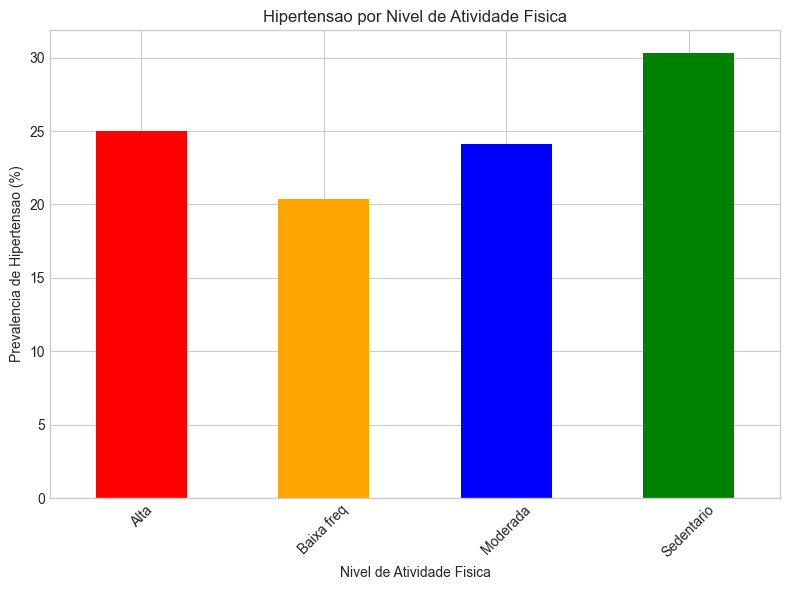


ATIVIDADE ATIVA:
atividade_ativo
False    52980
True     34677
Name: count, dtype: Int64


In [48]:
# atividade fisica vs hipertensao
if 'atividade_status' in df_final.columns:
    ativ_labels = {0: 'Sedentario', 1: 'Baixa freq', 2: 'Moderada', 3: 'Alta'}
    df_final['atividade_label'] = df_final['atividade_status'].map(ativ_labels)
    
    print("PREVALENCIA DE HIPERTENSAO POR NIVEL DE ATIVIDADE FISICA (%)")
    prev_ativ = df_final.groupby('atividade_label')['hipertensao'].mean() * 100
    print(prev_ativ)
    
    prev_ativ.plot(kind='bar', figsize=(8, 6), color=['red', 'orange', 'blue', 'green'])
    plt.xlabel('Nivel de Atividade Fisica')
    plt.ylabel('Prevalencia de Hipertensao (%)')
    plt.title('Hipertensao por Nivel de Atividade Fisica')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("\nATIVIDADE ATIVA:")
    print(df_final['atividade_ativo'].value_counts())

PREVALENCIA DE HIPERTENSAO POR INTENSIDADE DE ALCOOL (%)
alcool_label
Frequente    25.834543
Moderado     18.882107
Nao bebe     31.929602
Raro         21.566477
Name: hipertensao, dtype: float64


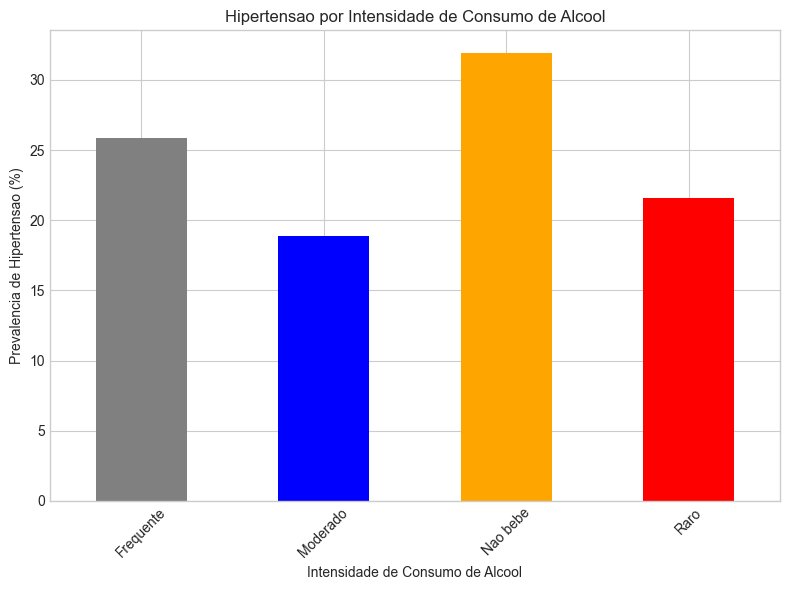


ALCOOL ATIVO:
alcool_ativo
False    52831
True     34826
Name: count, dtype: Int64


In [49]:
# alcool vs hipertensao
if 'alcool_status' in df_final.columns:
    alcool_labels = {0: 'Nao bebe', 1: 'Raro', 2: 'Moderado', 3: 'Frequente'}
    df_final['alcool_label'] = df_final['alcool_status'].map(alcool_labels)
    
    print("PREVALENCIA DE HIPERTENSAO POR INTENSIDADE DE ALCOOL (%)")
    prev_alcool = df_final.groupby('alcool_label')['hipertensao'].mean() * 100
    print(prev_alcool)
    
    prev_alcool.plot(kind='bar', figsize=(8, 6), color=['gray', 'blue', 'orange', 'red'])
    plt.xlabel('Intensidade de Consumo de Alcool')
    plt.ylabel('Prevalencia de Hipertensao (%)')
    plt.title('Hipertensao por Intensidade de Consumo de Alcool')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("\nALCOOL ATIVO:")
    print(df_final['alcool_ativo'].value_counts())

## 11. Salvar dados processados

In [50]:
# salvar arquivo final
output_path = '../data/processed/pns_2019_preprocessed.csv'
df_final.to_csv(output_path, index=False)
print(f"Dados processados salvos em: {output_path}")
print(f"Shape final: {df_final.shape}")

Dados processados salvos em: ../data/processed/pns_2019_preprocessed.csv
Shape final: (87657, 76)


## Resumo

Pipeline executado com sucesso:
1. Selecao de features
2. Limpeza e filtragem
3. Feature engineering
4. Transformacoes estatisticas


## 12. Bloco adicional organizado (socioeconomia, territorio e qualidade de vida)

Esta seção fica no final para facilitar controle de execução.

Objetivos deste bloco:
- analisar domicilio, internet e plano de saude vs doenca cronica
- analisar distribuicao de doenca cronica por UF
- analisar renda, escolaridade, plano, moradia e raca vs doenca cronica
- analisar qualidade de vida (imc, atividade, tabagismo, alcool) vs renda, escolaridade e moradia

### 12.1 Preparacao das variaveis auxiliares

Aqui montamos labels (UF, moradia, raca), quartis de renda e dataframe auxiliar para as tabelas/graficos.

In [51]:
df_ana = df_final.copy()

# alvo binario (qualquer doenca cronica)
if 'doenca_cronica' not in df_ana.columns and 'n_doencas' in df_ana.columns:
    df_ana['doenca_cronica'] = (df_ana['n_doencas'] > 0).astype('Int64')

# UF a partir dos dummies
uf_cols = [c for c in df_ana.columns if c.startswith('uf_')]
if uf_cols:
    uf_mat = df_ana[uf_cols].astype(int)
    uf_any = uf_mat.sum(axis=1) > 0
    uf_estado = uf_mat.idxmax(axis=1).str.replace('uf_', '', regex=False)
    df_ana['uf_estado'] = np.where(uf_any, uf_estado, 'UF_base')
else:
    df_ana['uf_estado'] = 'UF_nao_disponivel'

# moradia a partir dos dummies
dom_cols = [c for c in df_ana.columns if c.startswith('domicilio_')]
if dom_cols:
    dom_mat = df_ana[dom_cols].astype(int)
    dom_any = dom_mat.sum(axis=1) > 0
    dom_tipo = dom_mat.idxmax(axis=1).str.replace('domicilio_', '', regex=False)
    df_ana['domicilio_tipo'] = np.where(dom_any, dom_tipo, 'Casa_base')
else:
    df_ana['domicilio_tipo'] = 'Nao_disponivel'

# raca a partir dos dummies
raca_cols = [c for c in df_ana.columns if c.startswith('raca_')]
if raca_cols:
    raca_mat = df_ana[raca_cols].astype(int)
    raca_any = raca_mat.sum(axis=1) > 0
    raca_tipo = raca_mat.idxmax(axis=1).str.replace('raca_', '', regex=False)
    df_ana['raca_label'] = np.where(raca_any, raca_tipo, 'Branca_base')
else:
    df_ana['raca_label'] = 'Nao_disponivel'

# labels basicos
if 'plano_saude' in df_ana.columns:
    df_ana['plano_saude_label'] = df_ana['plano_saude'].map({1: 'Tem plano', 0: 'Nao tem plano'})
if 'acesso_internet' in df_ana.columns:
    df_ana['internet_label'] = df_ana['acesso_internet'].map({1: 'Tem internet', 0: 'Nao tem internet'})
if 'situacao_domicilio' in df_ana.columns:
    df_ana['situacao_domicilio_label'] = df_ana['situacao_domicilio'].map({1: 'Urbano', 2: 'Rural'})

# renda de referencia e quartis
if 'renda_per_capita' in df_ana.columns:
    df_ana['renda_ref'] = df_ana['renda_per_capita']
elif 'renda_per_capita_log' in df_ana.columns:
    df_ana['renda_ref'] = np.expm1(df_ana['renda_per_capita_log'])
else:
    df_ana['renda_ref'] = np.nan

if df_ana['renda_ref'].notna().sum() > 10:
    df_ana['quartil_renda'] = pd.qcut(
        df_ana['renda_ref'].rank(method='first'),
        q=4,
        labels=['Q1 (menor)', 'Q2', 'Q3', 'Q4 (maior)']
    )

print('Preparacao concluida:', df_ana.shape)

Preparacao concluida: (87657, 83)


### 12.2 Domicilio, internet e plano de saude vs doenca cronica


situacao_domicilio_label:
                          count  prev_doenca_cronica_%
situacao_domicilio_label                              
Urbano                    67548                  44.43

internet_label:
                  count  prev_doenca_cronica_%
internet_label                                
Nao tem internet  20865                  50.09
Tem internet      66792                   41.3

plano_saude_label:
                   count  prev_doenca_cronica_%
plano_saude_label                              
Tem plano          20057                  48.66
Nao tem plano      67600                  41.83

domicilio_tipo:
                count  prev_doenca_cronica_%
domicilio_tipo                              
Apartamento     10601                  43.84
Casa_base       76819                  43.36
Cortico           237                  33.76


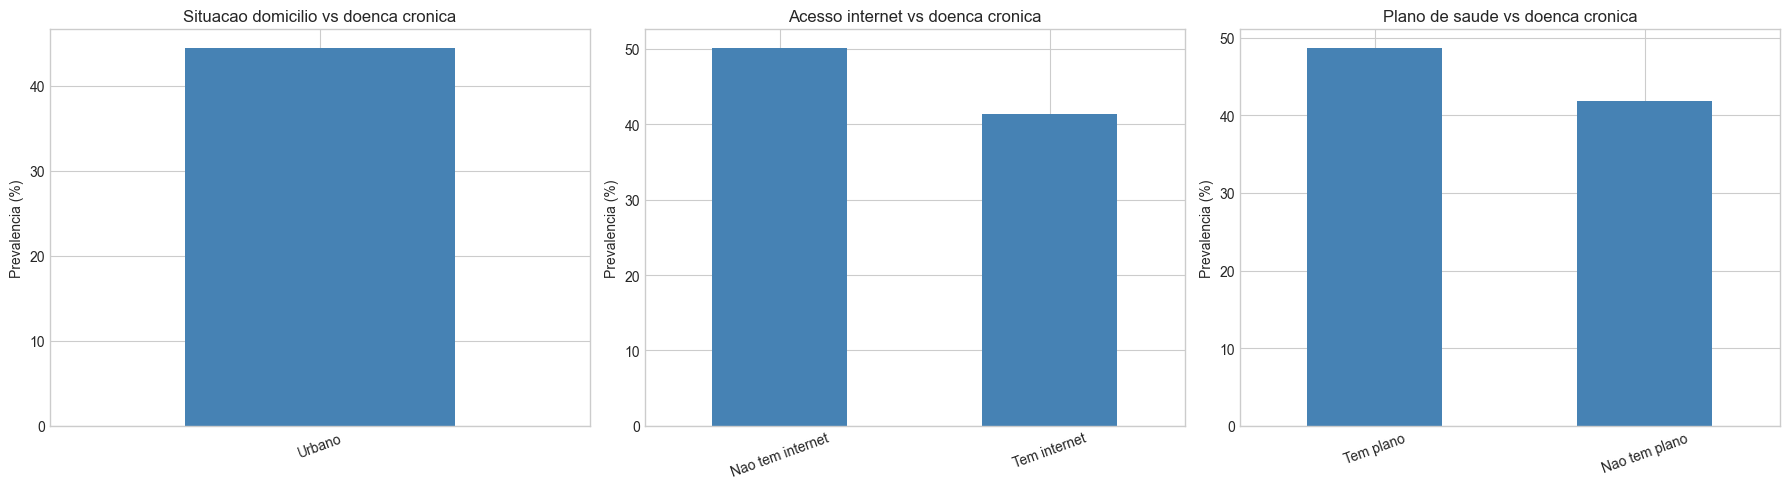

In [52]:
vars_base = ['situacao_domicilio_label', 'internet_label', 'plano_saude_label', 'domicilio_tipo']
for v in vars_base:
    if v in df_ana.columns and 'doenca_cronica' in df_ana.columns:
        tab = df_ana.groupby(v)['doenca_cronica'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        tab['prev_doenca_cronica_%'] = (tab['mean'] * 100).round(2)
        print(f'\n{v}:')
        print(tab[['count', 'prev_doenca_cronica_%']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_vars = [
    ('situacao_domicilio_label', 'Situacao domicilio'),
    ('internet_label', 'Acesso internet'),
    ('plano_saude_label', 'Plano de saude')
]
for i, (v, titulo) in enumerate(plot_vars):
    if v in df_ana.columns:
        s = (df_ana.groupby(v)['doenca_cronica'].mean() * 100).sort_values(ascending=False)
        s.plot(kind='bar', ax=axes[i], color='steelblue')
        axes[i].set_title(f'{titulo} vs doenca cronica')
        axes[i].set_ylabel('Prevalencia (%)')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### 12.3 Distribuicao de doenca cronica por UF

   uf_estado  prev_%
0         AL   42.96
1         AM   33.51
2         AP   36.24
3         BA   42.08
4         CE   41.18
5         DF   36.94
6         ES   48.15
7         GO   48.15
8         MA   35.33
9         MG   51.21
10        MS   45.89
11        MT   39.27
12        PA   34.36
13        PB   43.69
14        PE   42.27
15        PI   41.14
16        PR   48.11
17        RJ   48.33
18        RN   43.98
19        RO   37.61
20        RR   34.53
21        RS   54.75
22        SC   47.42
23        SE   45.09
24        SP    49.3
25        TO   40.44
26   UF_base   36.87


<Figure size 1000x1000 with 0 Axes>

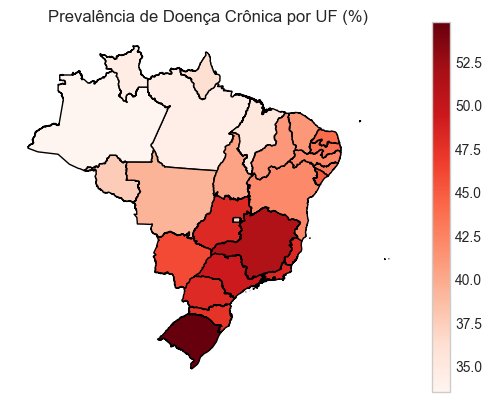

In [54]:
if 'uf_estado' in df_ana.columns and 'doenca_cronica' in df_ana.columns:
   
    prev_uf = (
        df_ana
        .groupby('uf_estado')['doenca_cronica']
        .mean()
        .mul(100)
        .round(2)
        .reset_index()
        .rename(columns={'doenca_cronica': 'prev_%'})
    )
    print(prev_uf)
    
    mapa = malha_territorial.merge(
        prev_uf,
        left_on="SIGLA_UF",
        right_on="uf_estado"
    )

    plt.figure(figsize=(10,10))

    mapa.plot(
        column="prev_%",
        cmap="Reds",
        legend=True,
        edgecolor="black"
    )

    plt.title("Prevalência de Doença Crônica por UF (%)")
    plt.axis("off")
    plt.show()

### 12.4 Renda, escolaridade e plano de saude vs doenca cronica

In [55]:
if 'quartil_renda' in df_ana.columns:
    t_renda = df_ana.groupby('quartil_renda', observed=False)['doenca_cronica'].mean() * 100
    print('Doenca cronica por quartil de renda (%):')
    print(t_renda.round(2))

if 'escolaridade_ord' in df_ana.columns:
    t_esc = df_ana.groupby('escolaridade_ord')['doenca_cronica'].mean() * 100
    print('\nDoenca cronica por escolaridade_ord (%):')
    print(t_esc.round(2))

if 'plano_saude_label' in df_ana.columns:
    t_plano = df_ana.groupby('plano_saude_label')['doenca_cronica'].mean() * 100
    print('\nDoenca cronica por plano de saude (%):')
    print(t_plano.round(2))

Doenca cronica por quartil de renda (%):
quartil_renda
Q1 (menor)    34.28
Q2            41.59
Q3            48.98
Q4 (maior)     48.7
Name: doenca_cronica, dtype: Float64

Doenca cronica por escolaridade_ord (%):
escolaridade_ord
0.0    59.34
1.0    50.72
2.0    34.95
3.0    40.94
4.0    44.96
Name: doenca_cronica, dtype: Float64

Doenca cronica por plano de saude (%):
plano_saude_label
Nao tem plano    41.83
Tem plano        48.66
Name: doenca_cronica, dtype: Float64


### 12.5 Raca, renda e doenca cronica

Doenca cronica por raca (%):
raca_label
Branca_base    46.81
Amarela         45.0
Preta          44.38
Parda           40.7
Indigena       40.48
Ignorado       22.22
Name: doenca_cronica, dtype: Float64


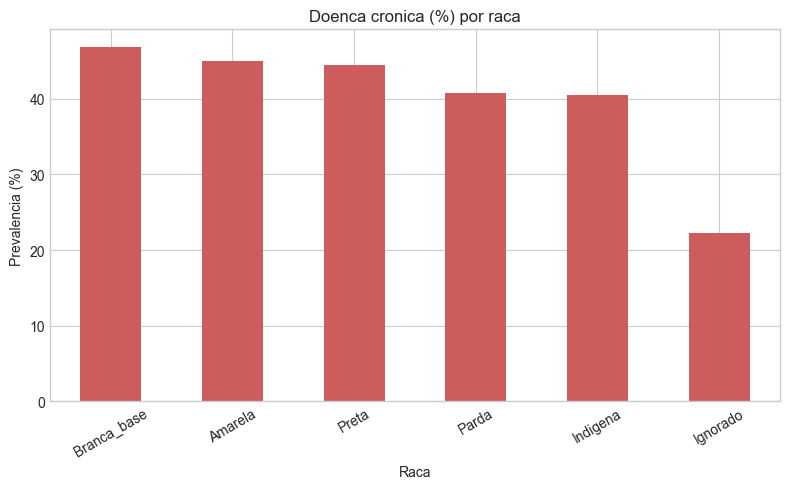


Doenca cronica por raca e quartil de renda (%):
quartil_renda  Q1 (menor)     Q2     Q3  Q4 (maior)
raca_label                                         
Amarela             35.51  38.13  44.97       52.45
Branca_base         36.39  43.91  50.66       49.59
Ignorado            100.0   <NA>  33.33         0.0
Indigena            33.78  39.41   48.2       46.94
Parda               32.87  40.23  47.24       47.17
Preta               37.72  42.67  50.72       48.54


In [ ]:
if 'raca_label' in df_ana.columns:
    t_raca = df_ana.groupby('raca_label')['doenca_cronica'].mean() * 100
    print('Doenca cronica por raca (%):')
    print(t_raca.sort_values(ascending=False).round(2))

    plt.figure(figsize=(8, 5))
    t_raca.sort_values(ascending=False).plot(kind='bar', color='indianred')
    plt.title('Doenca cronica (%) por raca')
    plt.ylabel('Prevalencia (%)')
    plt.xlabel('Raca')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

if 'raca_label' in df_ana.columns and 'quartil_renda' in df_ana.columns:
    t_raca_renda = (df_ana.groupby(['raca_label', 'quartil_renda'], observed=False)['doenca_cronica'].mean() * 100).unstack()
    print('\nDoenca cronica por raca e quartil de renda (%):')
    print(t_raca_renda.round(2))

### 12.6 Qualidade de vida vs renda, escolaridade e moradia

Definicao usada:
- imc_bom: IMC entre 18.5 e 24.9
- atividade_boa: nivel moderado/alto
- tabagismo_bom: nao fumar atualmente
- alcool_bom: nao estar no consumo mais alto

Score final: `qv_score` (0 a 4) e `qv_boa` (score >= 3).

Distribuicao do score de qualidade de vida:
qv_score
0      613
1     6779
2    39975
3    32995
4     7295
Name: count, dtype: int64

Boa qualidade de vida por quartil de renda (%):
quartil_renda
Q1 (menor)    43.39
Q2            44.25
Q3            44.98
Q4 (maior)    51.23
Name: qv_boa, dtype: float64

Boa qualidade de vida por escolaridade_ord (%):
escolaridade_ord
0.0    37.44
1.0    38.38
2.0    48.22
3.0    55.64
4.0    61.00
Name: qv_boa, dtype: float64

Boa qualidade de vida por tipo de domicilio (%):
domicilio_tipo
Apartamento    55.08
Casa_base      44.71
Cortico        43.04
Name: qv_boa, dtype: float64


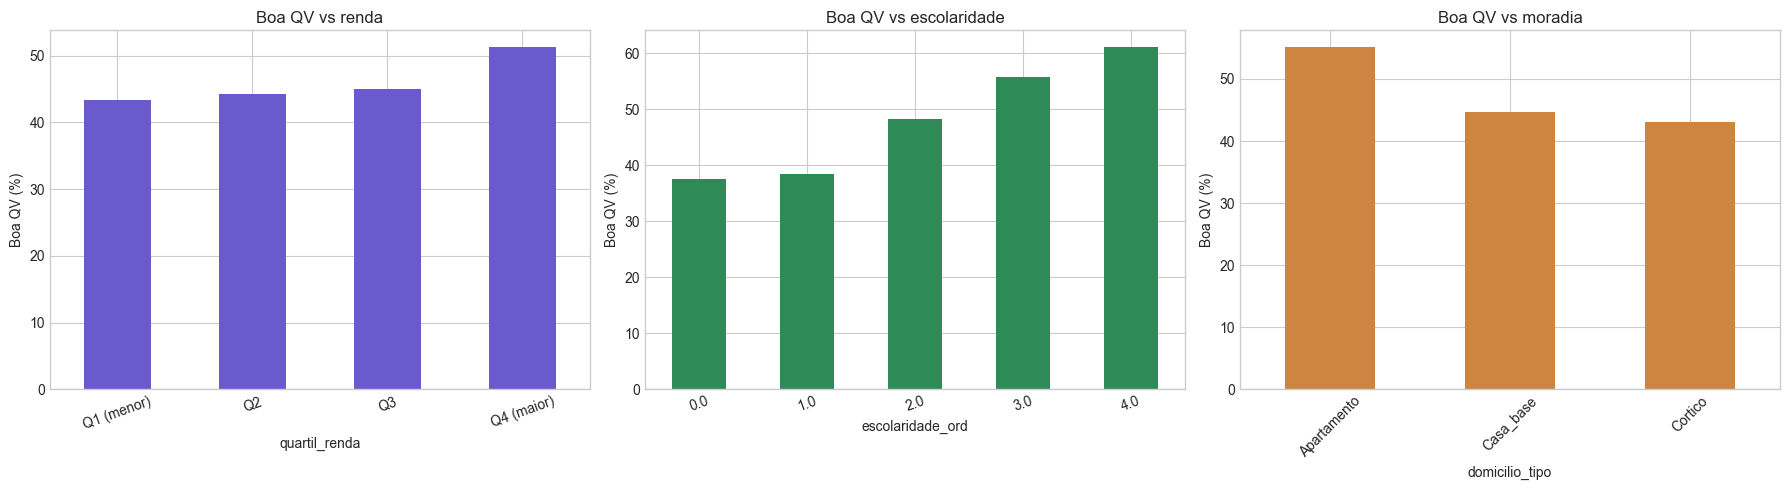

In [ ]:
# componentes de qualidade de vida
if 'imc' in df_ana.columns:
    df_ana['imc_bom'] = df_ana['imc'].between(18.5, 24.9, inclusive='both')
else:
    df_ana['imc_bom'] = False

if 'atividade_status' in df_ana.columns:
    df_ana['atividade_boa'] = df_ana['atividade_status'] >= 2
elif 'atividade_2' in df_ana.columns and 'atividade_3' in df_ana.columns:
    df_ana['atividade_boa'] = df_ana['atividade_2'] | df_ana['atividade_3']
else:
    df_ana['atividade_boa'] = False

if 'tabagismo_status' in df_ana.columns:
    df_ana['tabagismo_bom'] = df_ana['tabagismo_status'] < 2
elif 'tabagismo_2' in df_ana.columns:
    df_ana['tabagismo_bom'] = ~df_ana['tabagismo_2']
else:
    df_ana['tabagismo_bom'] = False

if 'alcool_status' in df_ana.columns:
    df_ana['alcool_bom'] = df_ana['alcool_status'] <= 2
elif 'alcool_3' in df_ana.columns:
    df_ana['alcool_bom'] = ~df_ana['alcool_3']
else:
    df_ana['alcool_bom'] = False

componentes_qv = ['imc_bom', 'atividade_boa', 'tabagismo_bom', 'alcool_bom']
df_ana['qv_score'] = df_ana[componentes_qv].astype(int).sum(axis=1)
df_ana['qv_boa'] = df_ana['qv_score'] >= 3

print('Distribuicao do score de qualidade de vida:')
print(df_ana['qv_score'].value_counts().sort_index())

if 'quartil_renda' in df_ana.columns:
    qv_renda = df_ana.groupby('quartil_renda', observed=False)['qv_boa'].mean() * 100
    print('\nBoa qualidade de vida por quartil de renda (%):')
    print(qv_renda.round(2))

if 'escolaridade_ord' in df_ana.columns:
    qv_esc = df_ana.groupby('escolaridade_ord')['qv_boa'].mean() * 100
    print('\nBoa qualidade de vida por escolaridade_ord (%):')
    print(qv_esc.round(2))

if 'domicilio_tipo' in df_ana.columns:
    qv_dom = df_ana.groupby('domicilio_tipo')['qv_boa'].mean() * 100
    print('\nBoa qualidade de vida por tipo de domicilio (%):')
    print(qv_dom.sort_values(ascending=False).round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if 'quartil_renda' in df_ana.columns:
    (df_ana.groupby('quartil_renda', observed=False)['qv_boa'].mean() * 100).plot(kind='bar', ax=axes[0], color='slateblue')
    axes[0].set_title('Boa QV vs renda')
    axes[0].set_ylabel('Boa QV (%)')
    axes[0].tick_params(axis='x', rotation=20)

if 'escolaridade_ord' in df_ana.columns:
    (df_ana.groupby('escolaridade_ord')['qv_boa'].mean() * 100).plot(kind='bar', ax=axes[1], color='seagreen')
    axes[1].set_title('Boa QV vs escolaridade')
    axes[1].set_ylabel('Boa QV (%)')
    axes[1].tick_params(axis='x', rotation=20)

if 'domicilio_tipo' in df_ana.columns:
    (df_ana.groupby('domicilio_tipo')['qv_boa'].mean() * 100).sort_values(ascending=False).plot(kind='bar', ax=axes[2], color='peru')
    axes[2].set_title('Boa QV vs moradia')
    axes[2].set_ylabel('Boa QV (%)')
    axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()